# Statistiques descriptives — Base GDELT GKG (2015 → aujourd'hui)

Ce notebook explore la base Parquet hebdomadaire produite par `gdelt_weekly_pipeline.py`.

**Rappel du schéma de chaque fichier `gdelt_YYYY-MM.parquet` :**

| Colonne | Description |
|---|---|
| `GKGRECORDID` | identifiant unique de l'enregistrement GKG |
| `DATE` | horodatage GDELT au format `YYYYMMDDHHMMSS` (string) |
| `SourceCollectionIdentifier` | canal de collecte GDELT (1=WEB, 2=CITATIONONLY, 3=CORE, 4=DTIC, 5=JSTOR, 6=NONTEXTUALSOURCE — d'après la documentation GDELT) |
| `DocumentIdentifier` | URL de l'article source |
| `EnhancedThemes` | thèmes GKG (format `THEME,offset;THEME,offset;...`) |
| `EnhancedLocations` | lieux géolocalisés détectés |
| `Persons` | personnes citées (séparées par `;`) |
| `Organizations` | organisations citées (séparées par `;`) |
| `TranslationInfo` | infos de traduction (si article non anglophone) |
| `Tone` | tonalité moyenne de l'article (échelle GDELT, -100 à +100) |
| `WordCount` | nombre de mots approximatif de l'article |
| `translated` | 1 si l'article provient de la master list translingue, 0 sinon |
| `SourceCommonName_ID` | identifiant entier du média, à mapper via `gdelt_sources_mapping.json` |

**DuckDB** : interroger directement les fichiers Parquet sans tout charger en RAM 
    
**pandas/matplotlib/seaborn** : agrégations plus fines et visualisations


## 1. Installation, imports and loadings

In [1]:
import os
import glob
import json
from pathlib import Path

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Configuration visuelle globale
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- A. INVENTAIRE PARQUET ---
DATA_DIR = Path("./gdelt_parquet_db")
SOURCE_MAP_PATH = Path("./gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f" {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")

# --- B. CONNEXION DUCKDB ET VUE BRUTE ---
con = duckdb.connect()
con.execute("PRAGMA memory_limit='200GB'")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")

# --- C. CHARGEMENT DU DICTIONNAIRE JSON ---
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print(" Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB")

 137 fichiers parquet trouvés (414.49 Go).
 Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB


## 2. Nettoyage de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.

In [2]:
print("Création de la vue 'gkg_clean' (Filtrage et réparation des sources)...")

con.execute(r"""
    CREATE OR REPLACE VIEW gkg_clean AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE 
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

# Bilan du nettoyage
bilan_nettoyage = con.execute("""
    SELECT 
        '1. GKG Brut' AS Etape, COUNT(*) AS Lignes_Totales 
    FROM gkg
    UNION ALL
    SELECT 
        '2. GKG Clean', COUNT(*) 
    FROM gkg_clean
""").df()

bilan_nettoyage['Lignes_Supprimees'] = bilan_nettoyage['Lignes_Totales'].iloc[0] - bilan_nettoyage['Lignes_Totales']
display(bilan_nettoyage.style.format({'Lignes_Totales': '{:,}', 'Lignes_Supprimees': '{:,}'}).hide(axis="index"))
print("Nettoyage terminé, la vue 'gkg_clean' est prête.")

Création de la vue 'gkg_clean' (Filtrage et réparation des sources)...


Etape,Lignes_Totales,Lignes_Supprimees
1. GKG Brut,"1,580,905,613",0
2. GKG Clean,"1,580,880,862","24,751"


Nettoyage terminé, la vue 'gkg_clean' est prête.


## 3. Description of the database

In [4]:
# 1. Aperçu du Schéma
print("Schéma de la table nettoyée :")
display(con.execute("DESCRIBE gkg_clean").df())

# 2. Aperçu des données (Head)
print("\n Aperçu des 5 premières lignes :")
display(con.execute("SELECT * FROM gkg_clean LIMIT 5").df())

Schéma de la table nettoyée :


,column_name,column_type,null,key,default,extra
0,GKGRECORDID,VARCHAR,YES,None,None,None
1,DATE,VARCHAR,YES,None,None,None
2,SourceCollectionIdentifier,TINYINT,YES,None,None,None
3,DocumentIdentifier,VARCHAR,YES,None,None,None
4,EnhancedThemes,VARCHAR,YES,None,None,None
5,EnhancedLocations,VARCHAR,YES,None,None,None
6,Persons,VARCHAR,YES,None,None,None
7,Organizations,VARCHAR,YES,None,None,None
8,TranslationInfo,VARCHAR,YES,None,None,None
9,IsTranslingual,TINYINT,YES,None,None,None



 Aperçu des 5 premières lignes :


,GKGRECORDID,DATE,SourceCollectionIdentifier,DocumentIdentifier,EnhancedThemes,EnhancedLocations,Persons,Organizations,TranslationInfo,IsTranslingual,Tone,WordCount,SourceCommonName_ID
0,20150221021500-0,20150221021500,1,http://www.fox17.com/template/inews_wire/wires...,"GENERAL_GOVERNMENT,451;ARMEDCONFLICT,73;ARMEDC...",1#Libya#OD#LY##25#17#LY#769;1#Yemen#OD#YM##15#...,,international news;associated press;world food...,,0,-8.18,140,324
1,20150221021500-1,20150221021500,1,http://www.groundzeromedia.org/pessimism-is-op...,"ARMEDCONFLICT,284;ARMEDCONFLICT,1140;ARMEDCONF...",1#Russia#GM#RS##60#100#RS#4382;1#Russia#GM#RS#...,mars mars;barack obama;lindsey graham;emmanuel...,european union;united nations;cnn;united states,,0,-3.93,2480,13428
2,20150221021500-2,20150221021500,1,http://www.archdaily.com/199601/lucien-pellat-...,"TAX_WORLDFISH,1390;NATURAL_DISASTER,417;TAX_FN...","4#Osaka, Osaka, Japan#JA#JA32#35840#34.6667#13...",lucien pellar-finet,coronet corporation,,0,0.76,233,234
3,20150221021500-3,20150221021500,1,http://www.voiceofalexandria.com/news/national...,"TAX_FNCACT,1334;TAX_FNCACT,2315;GENERAL_HEALTH...","2#Florida, United States#US#USFL##27.8333#-81....",hillary rodham clinton;wasserman schultz;john ...,democratic national committee;associated press,,0,-2.00,414,792
4,20150221021500-4,20150221021500,1,http://www.woodfordtimes.com/article/ZZ/201502...,"TAX_ETHNICITY,780;TAX_FNCACT,50;KILL,195;TAX_F...",,harris wittels;los angeles;amy poehler;hollywo...,,,0,-1.20,218,15542


In [5]:
audit_query = """
-- 1. VOLUME ET UNICITÉ
SELECT '1. Volume & Unicité' AS Categorie, 'Nombre total d''articles' AS Indicateur, CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut FROM gkg_clean
UNION ALL
SELECT '1. Volume & Unicité', 'Doublons sur GKGRECORDID', CAST(COUNT(*) - COUNT(DISTINCT GKGRECORDID) AS VARCHAR), CASE WHEN COUNT(*) = COUNT(DISTINCT GKGRECORDID) THEN '✅' ELSE '⚠️' END FROM gkg_clean

-- 2. CONFORMITÉ DES FORMATS
UNION ALL
SELECT '2. Conformité', 'URLs invalides (pas HTTP) sur Source=1', CAST(COUNT(*) AS VARCHAR), CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE SourceCollectionIdentifier = 1 AND DocumentIdentifier NOT ILIKE 'http%'
UNION ALL
SELECT '2. Conformité', 'IsTranslingual (valeurs hors 0/1)', CAST(COUNT(*) AS VARCHAR), CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE IsTranslingual NOT IN (0, 1)

-- 3. COMPLÉTUDE
UNION ALL
SELECT '3. Complétude (Critique)', 'GKGRECORDID / DATE / URL (% Vides)', CAST(ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM gkg_clean), 4) AS VARCHAR) || ' %', CASE WHEN COUNT(*) = 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean WHERE GKGRECORDID IS NULL OR DATE IS NULL OR DocumentIdentifier IS NULL OR DocumentIdentifier = ''
UNION ALL
SELECT '3. Complétude (Information)', 'EnhancedThemes (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'EnhancedLocations (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN EnhancedLocations IS NULL OR EnhancedLocations = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'Persons (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN Persons IS NULL OR Persons = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean
UNION ALL
SELECT '3. Complétude (Information)', 'Organizations (% Vides)', CAST(ROUND(100.0 * SUM(CASE WHEN Organizations IS NULL OR Organizations = '' THEN 1 ELSE 0 END) / COUNT(*), 2) AS VARCHAR) || ' %', 'ℹ️' FROM gkg_clean

-- 4. PROFILING NUMÉRIQUE
UNION ALL
SELECT '4. Profiling Numérique', 'Tone (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(ROUND(MIN(Tone), 1) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.25), 1) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.50), 1) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(Tone), 2) AS VARCHAR) || ' | ' || CAST(ROUND(APPROX_QUANTILE(Tone, 0.75), 1) AS VARCHAR) || ' | ' || CAST(ROUND(MAX(Tone), 1) AS VARCHAR), 
    CASE WHEN MIN(Tone) >= -100 AND MAX(Tone) <= 100 THEN '✅' ELSE '⚠️' END FROM gkg_clean
UNION ALL
SELECT '4. Profiling Numérique', 'WordCount (Min | Q1 | Médiane | Moyenne | Q3 | Max)', 
    CAST(MIN(WordCount) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.25) AS INTEGER) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.50) AS INTEGER) AS VARCHAR) || ' | ' || CAST(ROUND(AVG(WordCount), 0) AS VARCHAR) || ' | ' || CAST(CAST(APPROX_QUANTILE(WordCount, 0.75) AS INTEGER) AS VARCHAR) || ' | ' || CAST(MAX(WordCount) AS VARCHAR), 
    CASE WHEN MIN(WordCount) >= 0 THEN '✅' ELSE '⚠️' END FROM gkg_clean

ORDER BY Categorie, Indicateur;
"""

dashboard_sante = con.execute(audit_query).df()

styled_dashboard = dashboard_sante.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur']) \
                                        .set_properties(**{'text-align': 'center'}, subset=['Statut']) \
                                        .hide(axis="index")
display(styled_dashboard)

Categorie,Indicateur,Valeur,Statut
1. Volume & Unicité,Doublons sur GKGRECORDID,0,✅
1. Volume & Unicité,Nombre total d'articles,1580880862,ℹ️
2. Conformité,IsTranslingual (valeurs hors 0/1),0,✅
2. Conformité,URLs invalides (pas HTTP) sur Source=1,0,✅
3. Complétude (Critique),GKGRECORDID / DATE / URL (% Vides),0.0 %,✅
3. Complétude (Information),EnhancedLocations (% Vides),21.78 %,ℹ️
3. Complétude (Information),EnhancedThemes (% Vides),9.27 %,ℹ️
3. Complétude (Information),Organizations (% Vides),31.8 %,ℹ️
3. Complétude (Information),Persons (% Vides),43.56 %,ℹ️
4. Profiling Numérique,Tone (Min | Q1 | Médiane | Moyenne | Q3 | Max),-100.0 | -3.2 | -0.6 | -0.89 | 1.6 | 100.0,✅


## 4. Popularity of themes, persons, organizations, locations and sources

In [6]:
con.execute("PRAGMA memory_limit='200GB'")

print("Tops on a uniform 10% sample (Hash Method)...")

# 2. Top 20 Themes
top_themes_sample = con.execute("""
    SELECT split_part(TRIM(theme_raw), ',', 1) AS Theme, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(EnhancedThemes, ';')) AS theme_raw
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    )
    WHERE TRIM(theme_raw) != ''
    GROUP BY Theme 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 3. Top 20 Persons
top_persons_sample = con.execute("""
    SELECT TRIM(person) AS Person, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(Persons, ';')) AS person
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND Persons IS NOT NULL AND Persons != ''
    )
    WHERE TRIM(person) != ''
    GROUP BY Person 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 4. Top 20 Organizations
top_orgs_sample = con.execute("""
    SELECT TRIM(org) AS Organization, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(Organizations, ';')) AS org
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND Organizations IS NOT NULL AND Organizations != ''
    )
    WHERE TRIM(org) != ''
    GROUP BY Organization 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 5. Top 20 Locations (Splitting on '#' to extract the readable name)
top_locs_sample = con.execute("""
    SELECT split_part(TRIM(loc), '#', 2) AS Location, COUNT(*) AS Citations
    FROM (
        SELECT UNNEST(string_split(EnhancedLocations, ';')) AS loc
        FROM gkg_clean
        WHERE hash(GKGRECORDID) % 10 = 0
          AND EnhancedLocations IS NOT NULL AND EnhancedLocations != ''
    )
    WHERE TRIM(loc) != '' AND split_part(TRIM(loc), '#', 2) != ''
    GROUP BY Location 
    ORDER BY Citations DESC 
    LIMIT 50
""").df()

# 6. Top 20 Sources (JOIN with src_map to get textual names)
top_sources_sample = con.execute("""
    SELECT m.SourceCommonName AS Source_Name, CAST(g.SourceCommonName_ID AS VARCHAR) AS Source_ID, COUNT(*) AS Articles
    FROM gkg_clean g
    JOIN src_map m ON g.SourceCommonName_ID = m.SourceCommonName_ID
    WHERE hash(g.GKGRECORDID) % 10 = 0
      AND g.SourceCommonName_ID IS NOT NULL
    GROUP BY m.SourceCommonName, g.SourceCommonName_ID
    ORDER BY Articles DESC 
    LIMIT 50
""").df()

# 6. Fonction pour afficher les DataFrames côte à côte (Corrigée pour éviter le chevauchement)
def display_side_by_side(dfs, titles):
    # 'flex: 0 0 auto' empêche l'écrasement, les tableaux iront à la ligne si l'écran est trop petit
    html_str = '<div style="display: flex; flex-wrap: wrap; gap: 30px; align-items: flex-start;">'
    
    for df, title in zip(dfs, titles):
        # On ajoute des règles CSS pour que le texte long revienne à la ligne proprement
        styled_df = df.style.format(thousands=",") \
                            .hide(axis="index") \
                            .set_table_styles([
                                {'selector': 'td, th', 
                                 'props': [('max-width', '250px'), 
                                           ('white-space', 'normal'), 
                                           ('word-wrap', 'break-word')]}
                            ])
        
        html_str += f'<div style="flex: 0 0 auto; overflow-x: auto;">'
        html_str += f'<h3 style="text-align: center; margin-bottom: 10px;">{title}</h3>'
        html_str += styled_df.to_html()
        html_str += '</div>'
        
    html_str += '</div>'
    display(HTML(html_str))

# 7. Affichage final
display_side_by_side(
    [top_themes_sample, top_persons_sample, top_orgs_sample, top_locs_sample, top_sources_sample], 
    ['Themes', 'Persons', 'Organizations', 'Locations', 'Sources']
)

Tops on a uniform 10% sample (Hash Method)...


Theme,Citations
USPEC_POLITICS_GENERAL1,"89,933,393"
CRISISLEX_C07_SAFETY,"85,762,489"
CRISISLEX_CRISISLEXREC,"84,161,311"
LEADER,"83,257,998"
GENERAL_HEALTH,"79,042,445"
GENERAL_GOVERNMENT,"75,238,744"
UNGP_FORESTS_RIVERS_OCEANS,"70,793,412"
MANMADE_DISASTER_IMPLIED,"69,652,596"
EPU_ECONOMY_HISTORIC,"69,403,701"
EDUCATION,"69,083,073"


First impression : there are some erros of classification between countries/people/organizations, for e.g. Los Angeles is listed as a person and United States as an organization. For the locations, it will be important to cover the whole lexical declination of a given country (France, French...)

## 5. Article/day analysis - descriptions and seasonality 

In [3]:
# Détection de jours manquants dans la collecte (utile pour évaluer la qualité du pipeline)
articles_per_day = con.execute("""
    SELECT STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE AS day,
           COUNT(*) AS n_articles
    FROM gkg_clean
    GROUP BY day
    ORDER BY day
""").df()

articles_per_day["day"] = pd.to_datetime(articles_per_day["day"])
articles_per_day = articles_per_day.set_index("day")

full_range = pd.date_range(articles_per_day.index.min(), articles_per_day.index.max(), freq="D")
missing_days = full_range.difference(articles_per_day.index)

print(f"Jours sans aucune donnée sur la période : {len(missing_days)} / {len(full_range)}")
if len(missing_days) > 0:
    print("Premiers jours manquants :", list(missing_days[:20].strftime('%Y-%m-%d')))


Jours sans aucune donnée sur la période : 17 / 4140
Premiers jours manquants : ['2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20', '2025-06-21', '2025-06-22', '2025-06-23', '2025-06-24', '2025-06-25', '2025-06-26', '2025-06-27', '2025-06-28', '2025-06-29', '2025-06-30', '2025-07-01']


In [18]:
print(f"Nombre de jours couverts par la collecte : {len(articles_per_day):,}")
print(f"Total d'articles                          : {articles_per_day['n_articles'].sum():,.0f}")
print(f"Moyenne d'articles / jour                 : {articles_per_day['n_articles'].mean():,.1f}")
print(f"Médiane d'articles / jour                 : {articles_per_day['n_articles'].median():,.1f}")
print(f"Écart-type / jour                         : {articles_per_day['n_articles'].std():,.1f}")
print(f"Min / jour                                : {articles_per_day['n_articles'].min():,.0f}")
print(f"Max / jour                                : {articles_per_day['n_articles'].max():,.0f}")


Nombre de jours couverts par la collecte : 4,123
Total d'articles                          : 1,580,880,862
Moyenne d'articles / jour                 : 383,429.8
Médiane d'articles / jour                 : 383,339.0
Écart-type / jour                         : 99,635.1
Min / jour                                : 16,596
Max / jour                                : 560,370


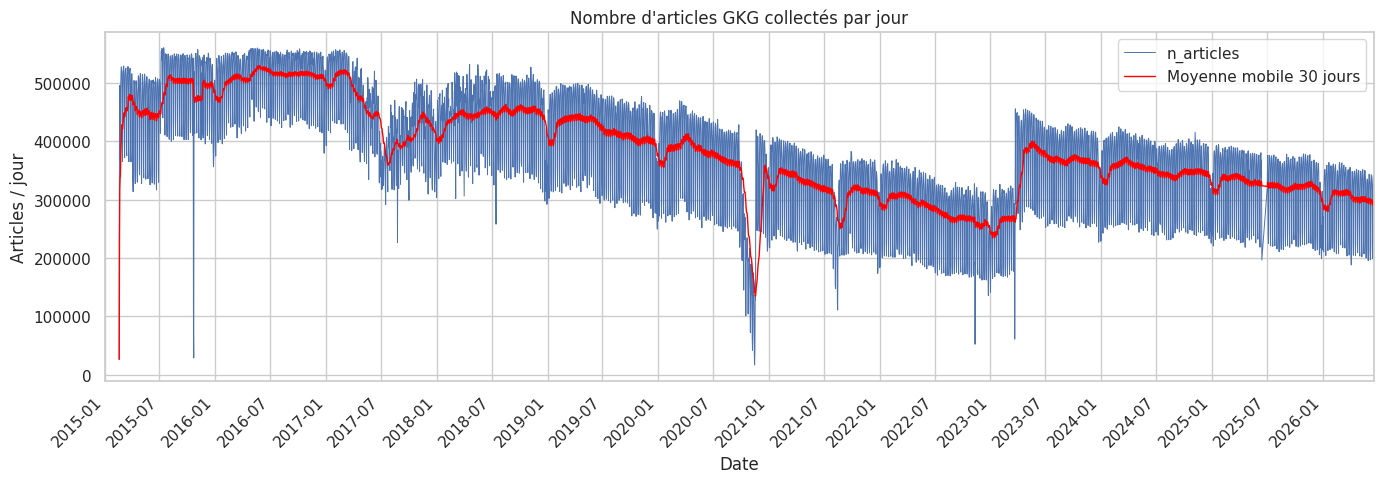

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(14, 5))

articles_per_day["n_articles"].plot(ax=ax, linewidth=0.7)
articles_per_day["n_articles"].rolling(30, min_periods=1).mean().plot(
    ax=ax, linewidth=1, color="red", label="Moyenne mobile 30 jours"
)

ax.set_title("Nombre d'articles GKG collectés par jour")
ax.set_ylabel("Articles / jour")
ax.set_xlabel("Date")

ax.set_xlim(pd.to_datetime('2015-01-01'), articles_per_day.index.max())

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)

ax.legend()
plt.tight_layout()
plt.show()

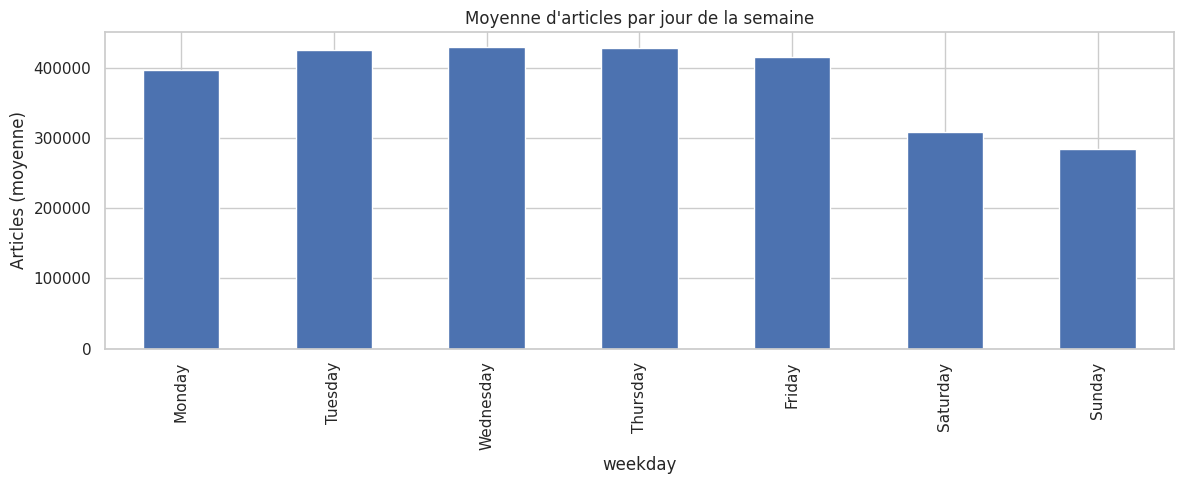

In [21]:
weekday_avg = (
    articles_per_day.assign(weekday=articles_per_day.index.day_name())
    .groupby("weekday")["n_articles"].mean()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

weekday_avg.plot(kind="bar")
plt.title("Moyenne d'articles par jour de la semaine")
plt.ylabel("Articles (moyenne)")
plt.tight_layout()
plt.show()


Calcul de l'ACF et PACF (100% Numpy/Pandas, sans statsmodels)...


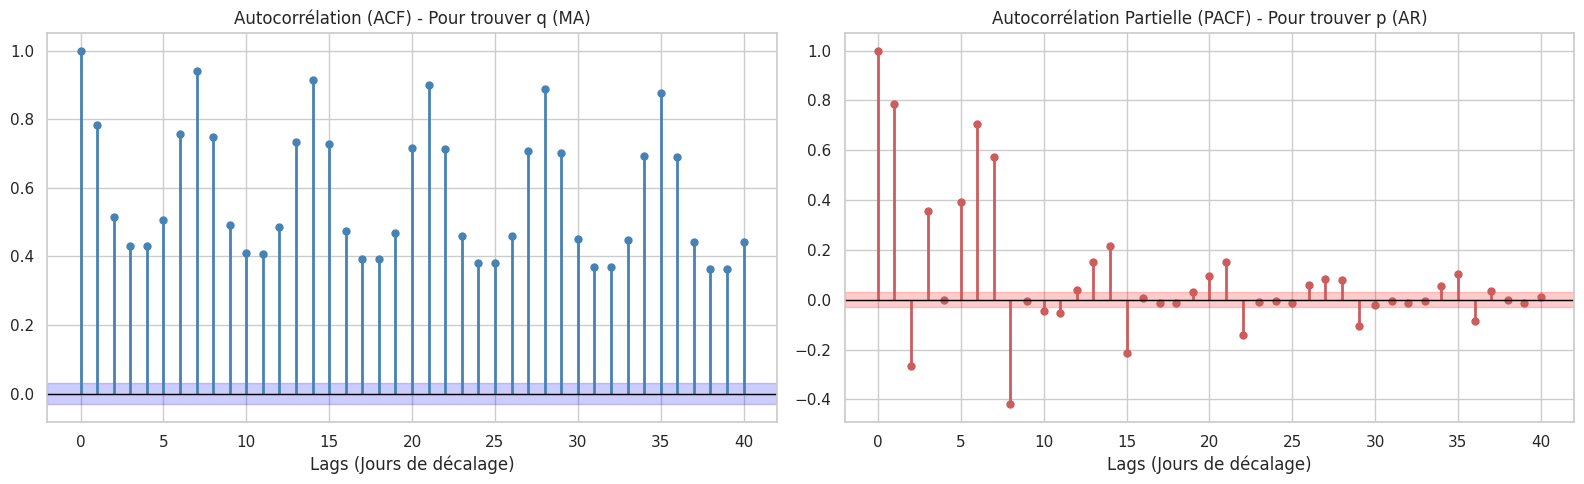

In [13]:
print("Calcul de l'ACF et PACF (100% Numpy/Pandas, sans statsmodels)...")

# 1. Préparation de la série (On comble les trous)
ts_data = articles_per_day["n_articles"].asfreq('D').ffill()
y = ts_data.values
n = len(y)
max_lag = 40

# --- CALCUL DE L'ACF ---
acf_vals = [1.0]
y_mean = np.mean(y)
y_var = np.sum((y - y_mean)**2)

for k in range(1, max_lag + 1):
    cov = np.sum((y[k:] - y_mean) * (y[:-k] - y_mean))
    acf_vals.append(cov / y_var)

# --- CALCUL DE LA PACF (via Moindres Carrés / OLS) ---
pacf_vals = [1.0]

for k in range(1, max_lag + 1):
    # Pour le lag k, on crée une matrice de variables explicatives (retards)
    X = np.zeros((n - k, k))
    for j in range(k):
        X[:, j] = y[k - 1 - j : n - 1 - j]
        
    # On ajoute une constante à la matrice
    X = np.column_stack([np.ones(n - k), X])
    Y_target = y[k:]

    # Résolution de l'équation linéaire (X * beta = Y) native avec numpy
    beta, _, _, _ = np.linalg.lstsq(X, Y_target, rcond=None)
    
    # La PACF correspond au tout dernier coefficient de la régression (le lag k)
    pacf_vals.append(beta[-1])

# --- AFFICHAGE GRAPHIQUE ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
lags = np.arange(max_lag + 1)
conf_interval = 1.96 / np.sqrt(n) # Ligne bleue de significativité (95%)

# Plot ACF
axes[0].vlines(lags, [0], acf_vals, color="steelblue", linewidth=2)
axes[0].plot(lags, acf_vals, marker='o', markersize=5, color="steelblue", linestyle='None')
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axhspan(-conf_interval, conf_interval, alpha=0.2, color="blue")
axes[0].set_title("Autocorrélation (ACF) - Pour trouver q (MA)")
axes[0].set_xlabel("Lags (Jours de décalage)")

# Plot PACF
axes[1].vlines(lags, [0], pacf_vals, color="indianred", linewidth=2)
axes[1].plot(lags, pacf_vals, marker='o', markersize=5, color="indianred", linestyle='None')
axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhspan(-conf_interval, conf_interval, alpha=0.2, color="red")
axes[1].set_title("Autocorrélation Partielle (PACF) - Pour trouver p (AR)")
axes[1].set_xlabel("Lags (Jours de décalage)")

plt.tight_layout()
plt.show()

1. ACF Plot (Autocorrelation Function)

The ACF values decrease very slowly and stay well above the blue confidence interval for many lags --> sign of a non-stationary time series, meaning the data has a strong underlying trend.

Tere are distinct, recurring peaks exactly every 7 days (at lags 7, 14, 21, 28, and 35). This confirms a very strong weekly seasonality in the volume of published articles.

2. PACF Plot (Partial Autocorrelation Function)

There are significant spikes at the very beginning (especially lags 1 and 2) that fall outside the red confidence band. This suggests that the value of today is heavily influenced by the previous 1 or 2 days, indicating an Autoregressive (AR) component (potentially p = 1 or p = 2).

There is a highly significant positive spike exactly at lag 7. This aligns with the ACF findings and confirms that the previous week's volume on the same day is a strong predictor for today's volume.

## 6. Tone analysis

Calcul du Tone sur 1% de la base (Méthode Hash % 100)...


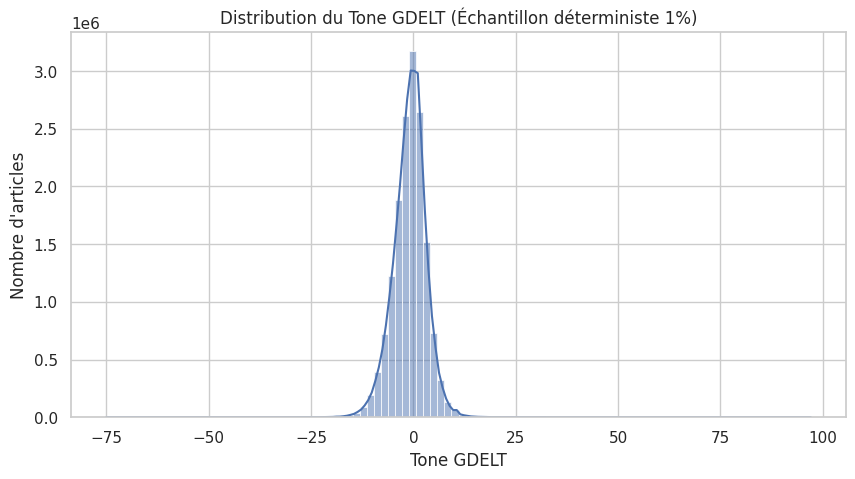

,count,mean,std,min,25%,50%,75%,max
Tone,"15,800,264.00",-0.89,3.98,-75.00,-3.23,-0.61,1.59,97.06


In [5]:
print("Calcul du Tone sur 1% de la base (Méthode Hash % 100)...")

tone_full = con.execute("""
    SELECT Tone 
    FROM gkg_clean 
    WHERE hash(GKGRECORDID) % 100 = 0
""").df()

# Visualisation
plt.figure(figsize=(10, 5))
sns.histplot(tone_full["Tone"], bins=100, kde=True)
plt.title("Distribution du Tone GDELT (Échantillon déterministe 1%)")
plt.xlabel("Tone GDELT")
plt.ylabel("Nombre d'articles")
plt.show()

# Statistiques descriptives
display(tone_full["Tone"].describe().to_frame().T)

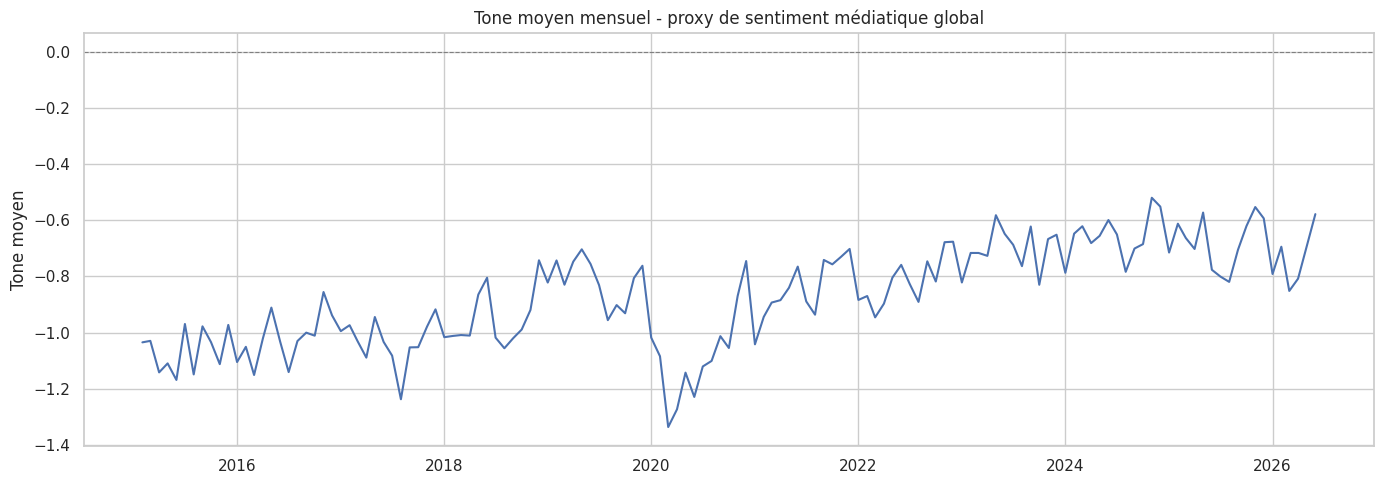

In [9]:
tone_monthly = con.execute("""
    SELECT DATE_TRUNC('month', STRPTIME(SUBSTR(DATE, 1, 8), '%Y%m%d')::DATE) AS month,
           AVG(Tone) AS avg_tone,
           COUNT(*) AS n
    FROM gkg_clean
    GROUP BY month
    ORDER BY month
""").df()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tone_monthly["month"], tone_monthly["avg_tone"])
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title("Tone moyen mensuel - proxy de sentiment médiatique global")
ax.set_ylabel("Tone moyen")
plt.tight_layout()
plt.show()


## 7. Themes analysis 

In [12]:
print("⏳ Calcul des co-occurrences optimisé...")

df_pairs = con.execute("""
    SELECT 
        theme1, theme2, COUNT(*) as weight
    FROM (
        SELECT 
            split_part(t1.raw_theme, ',', 1) AS theme1, 
            split_part(t2.raw_theme, ',', 1) AS theme2
        FROM (
            SELECT GKGRECORDID, TRIM(UNNEST(string_split(EnhancedThemes, ';'))) AS raw_theme
            FROM gkg_clean
            WHERE hash(GKGRECORDID) % 100 = 0 
              AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
        ) t1
        JOIN (
            SELECT GKGRECORDID, TRIM(UNNEST(string_split(EnhancedThemes, ';'))) AS raw_theme
            FROM gkg_clean
            WHERE hash(GKGRECORDID) % 100 = 0 
              AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
        ) t2 ON t1.GKGRECORDID = t2.GKGRECORDID
        -- On force l'ordre alphabétique (theme1 < theme2) pour éviter de compter A-B et B-A comme deux liens différents
        WHERE split_part(t1.raw_theme, ',', 1) < split_part(t2.raw_theme, ',', 1)
    )
    GROUP BY theme1, theme2
    HAVING weight > 500
    ORDER BY weight DESC
    LIMIT 500
""").df()

print(f"✅ Calcul terminé ! {len(df_pairs)} paires extraites.")

# Construction du graphe
import networkx as nx
G = nx.Graph()
for _, row in df_pairs.iterrows():
    G.add_edge(row['theme1'], row['theme2'], weight=row['weight'])

# Affichage simple pour valider
print(f"Graphe créé avec {G.number_of_nodes()} thèmes et {G.number_of_edges()} liens.")

⏳ Calcul des co-occurrences optimisé...
✅ Calcul terminé ! 500 paires extraites.
Graphe créé avec 143 thèmes et 500 liens.


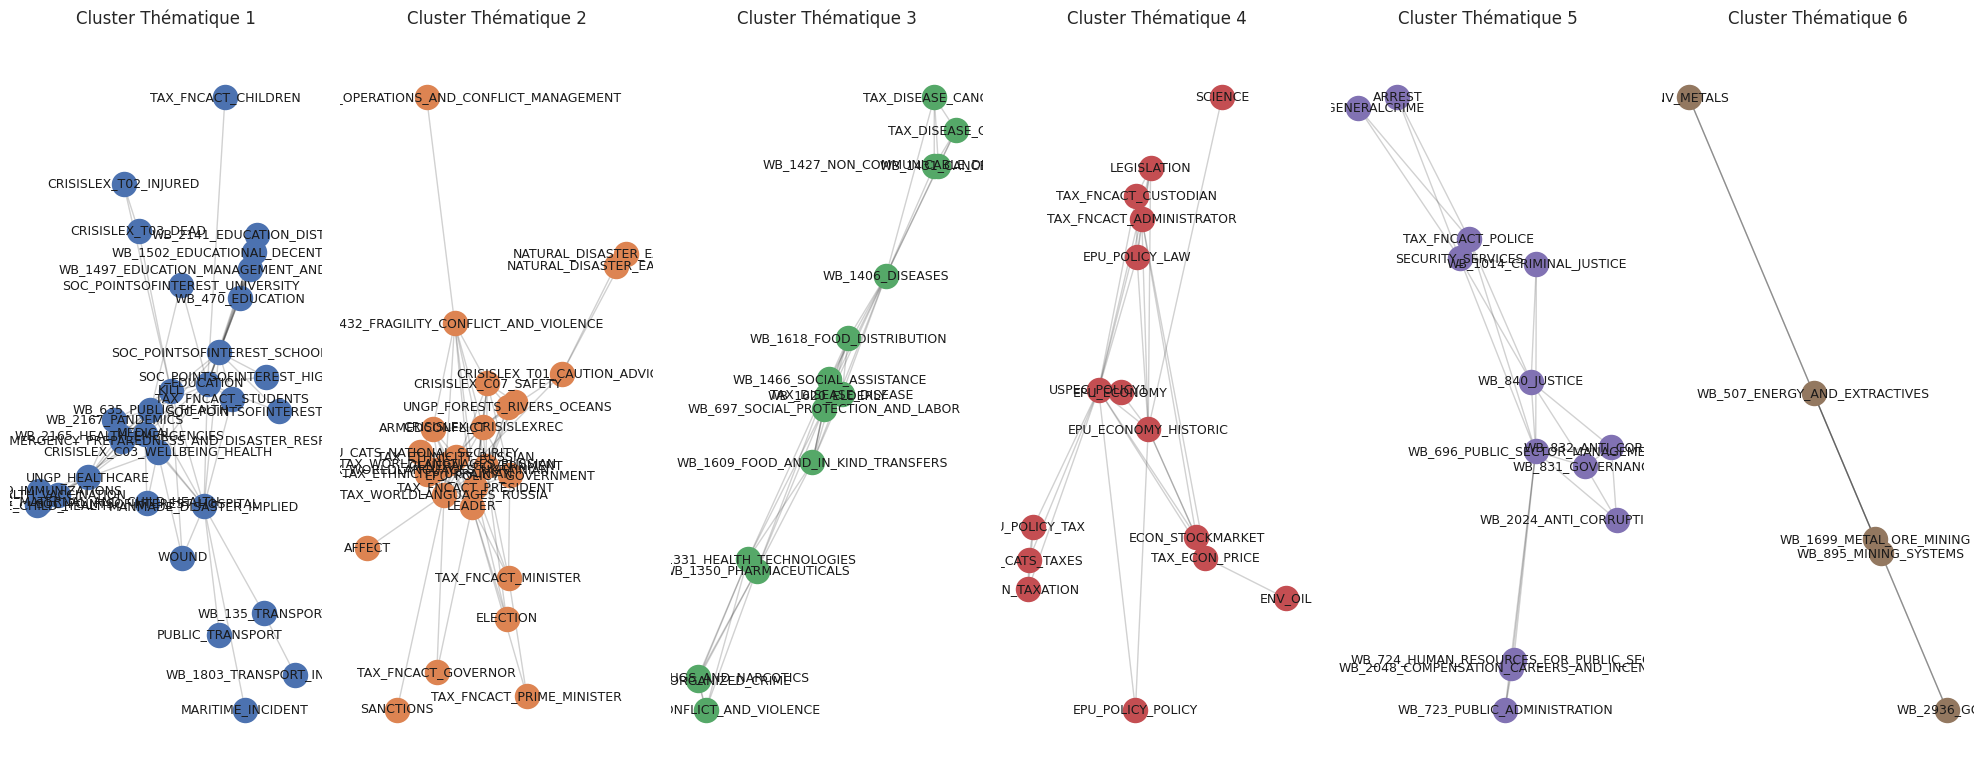

In [16]:
from networkx.algorithms import community

# 1. Utilisation de l'algorithme de Louvain (ou Greedy Modularity) pour trouver les groupes
communities = list(community.greedy_modularity_communities(G_filtered))

# 2. On ne garde que les 3 plus grosses communautés pour ne pas surcharger
num_clusters = min(len(communities), 6)
fig, axes = plt.subplots(1, num_clusters, figsize=(20, 8))

for i in range(num_clusters):
    cluster_nodes = list(communities[i])
    subgraph = G_filtered.subgraph(cluster_nodes)
    
    pos = nx.spring_layout(subgraph, k=1.5, iterations=50)
    nx.draw_networkx_nodes(subgraph, pos, ax=axes[i], node_size=300, node_color=f"C{i}")
    nx.draw_networkx_labels(subgraph, pos, ax=axes[i], font_size=9)
    nx.draw_networkx_edges(subgraph, pos, ax=axes[i], alpha=0.2)
    
    axes[i].set_title(f"Cluster Thématique {i+1}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

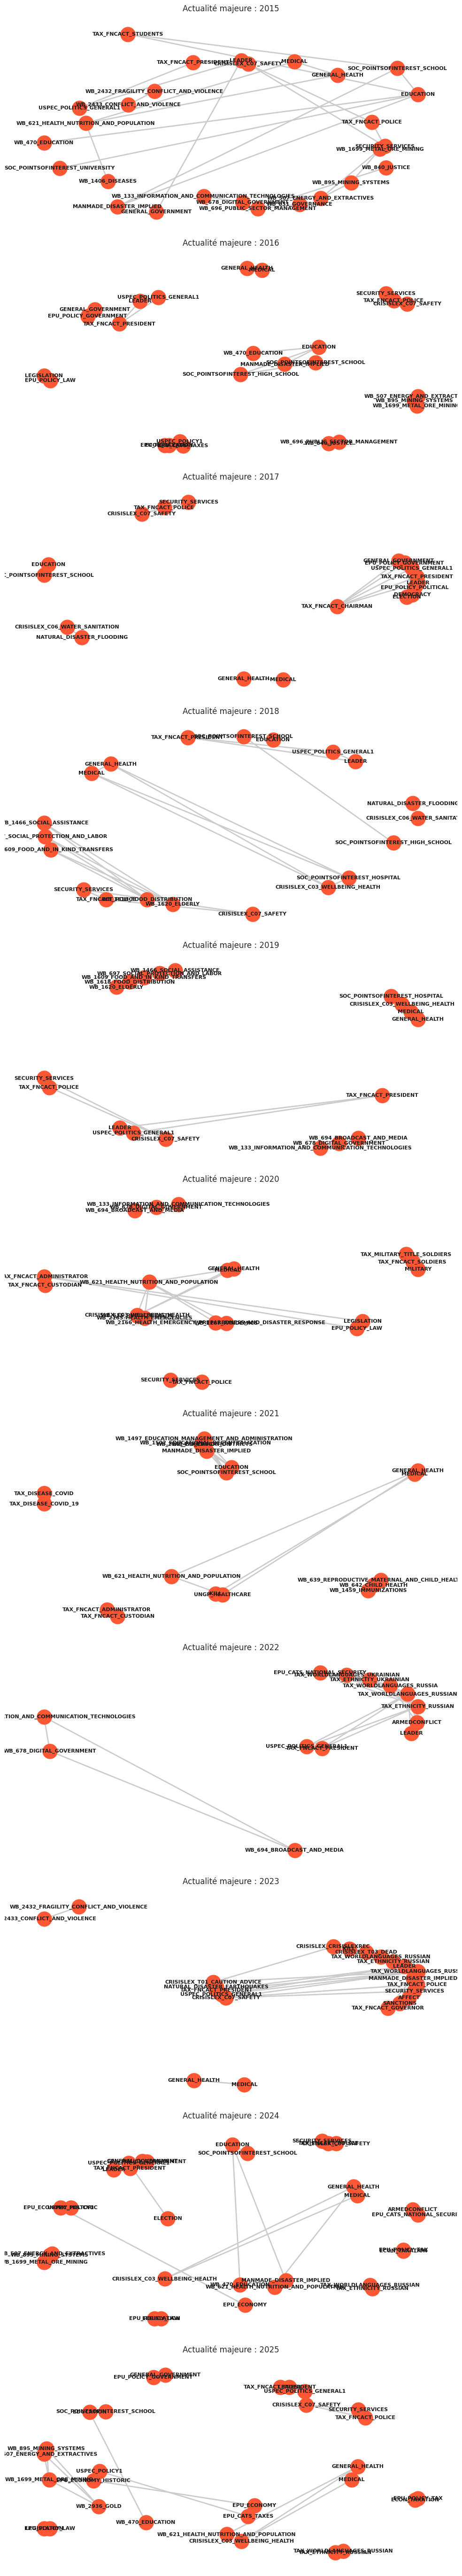

In [21]:
# Liste des années à traiter
annees = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Configuration de la grille
fig, axes = plt.subplots(len(annees), 1, figsize=(10, 5 * len(annees)))

for i, annee in enumerate(annees):
    ax = axes[i]
    
    # 1. Extraction rapide des co-occurrences (1% échantillon)
    df_pairs = con.execute(f"""
        SELECT theme1, theme2, COUNT(*) as weight
        FROM (
            SELECT split_part(t1.raw_theme, ',', 1) AS theme1, split_part(t2.raw_theme, ',', 1) AS theme2
            FROM (
                SELECT GKGRECORDID, TRIM(UNNEST(string_split(EnhancedThemes, ';'))) AS raw_theme
                FROM gkg_clean WHERE hash(GKGRECORDID) % 50 = 0 AND DATE LIKE '{annee}%'
                AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
            ) t1
            JOIN (
                SELECT GKGRECORDID, TRIM(UNNEST(string_split(EnhancedThemes, ';'))) AS raw_theme
                FROM gkg_clean WHERE hash(GKGRECORDID) % 50 = 0 AND DATE LIKE '{annee}%'
                AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
            ) t2 ON t1.GKGRECORDID = t2.GKGRECORDID
            WHERE split_part(t1.raw_theme, ',', 1) < split_part(t2.raw_theme, ',', 1)
        )
        GROUP BY theme1, theme2
        HAVING weight > 500
        ORDER BY weight DESC
        LIMIT 25
    """).df()
    
    if df_pairs.empty:
        ax.text(0.5, 0.5, 'Données manquantes', ha='center')
        continue

    # 2. Construction du graphe simplifié
    G = nx.Graph()
    for _, row in df_pairs.iterrows():
        G.add_edge(row['theme1'], row['theme2'], weight=row['weight'])
    
    # 3. Dessin épuré
    pos = nx.kamada_kawai_layout(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=500, node_color="#FF5733")
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, width=2, edge_color="#cccccc")
    
    ax.set_title(f"Actualité majeure : {annee}", fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

⏳ Calcul du sentiment par thème (Méthode CTE)...


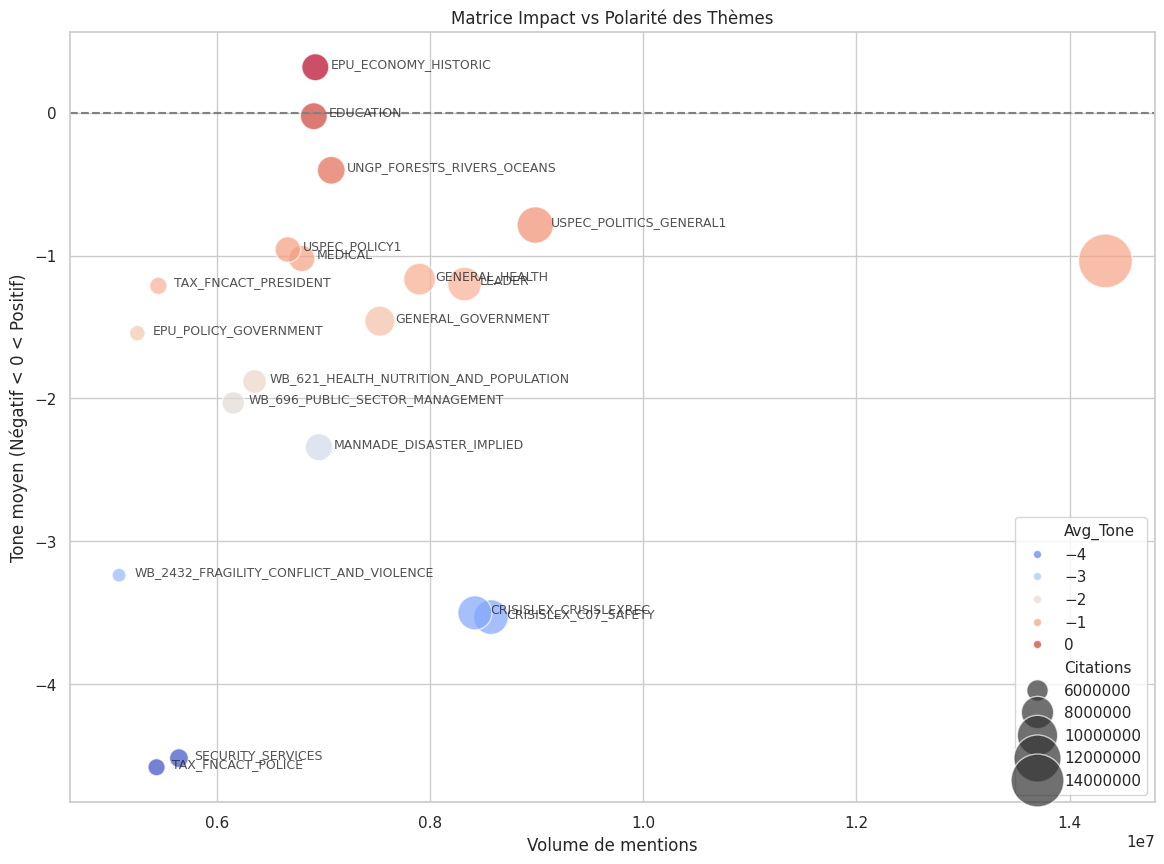

In [30]:
print("⏳ Calcul du sentiment par thème (Méthode CTE)...")

df_sentiment = con.execute("""
    WITH exploded_themes AS (
        SELECT 
            split_part(TRIM(theme), ',', 1) AS Theme,
            Tone
        FROM (
            SELECT UNNEST(string_split(EnhancedThemes, ';')) AS theme, Tone
            FROM gkg_clean
            WHERE hash(GKGRECORDID) % 100 = 0 
              AND EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
        )
    )
    SELECT 
        Theme, 
        COUNT(*) AS Citations,
        AVG(Tone) AS Avg_Tone
    FROM exploded_themes
    GROUP BY Theme
    HAVING Citations > 5000
    ORDER BY Citations DESC
    LIMIT 20
""").df()

plt.figure(figsize=(14, 10))
scatter = sns.scatterplot(data=df_sentiment, x="Citations", y="Avg_Tone", 
                          size="Citations", sizes=(100, 1500), 
                          hue="Avg_Tone", palette="coolwarm", alpha=0.7)

# --- AJOUT DES ANNOTATIONS ---
for i in range(df_sentiment.shape[0]):
    plt.text(
        x=df_sentiment.Citations[i] + (df_sentiment.Citations.max() * 0.01), 
        y=df_sentiment.Avg_Tone[i], 
        s=df_sentiment.Theme[i], 
        fontsize=9, 
        alpha=0.8
    )

plt.axhline(0, color='gray', linestyle='--')
plt.title("Matrice Impact vs Polarité des Thèmes")
plt.xlabel("Volume de mentions")
plt.ylabel("Tone moyen (Négatif < 0 < Positif)")
plt.show()

⏳ Calcul de la géographie thématique (Méthode CTE)...


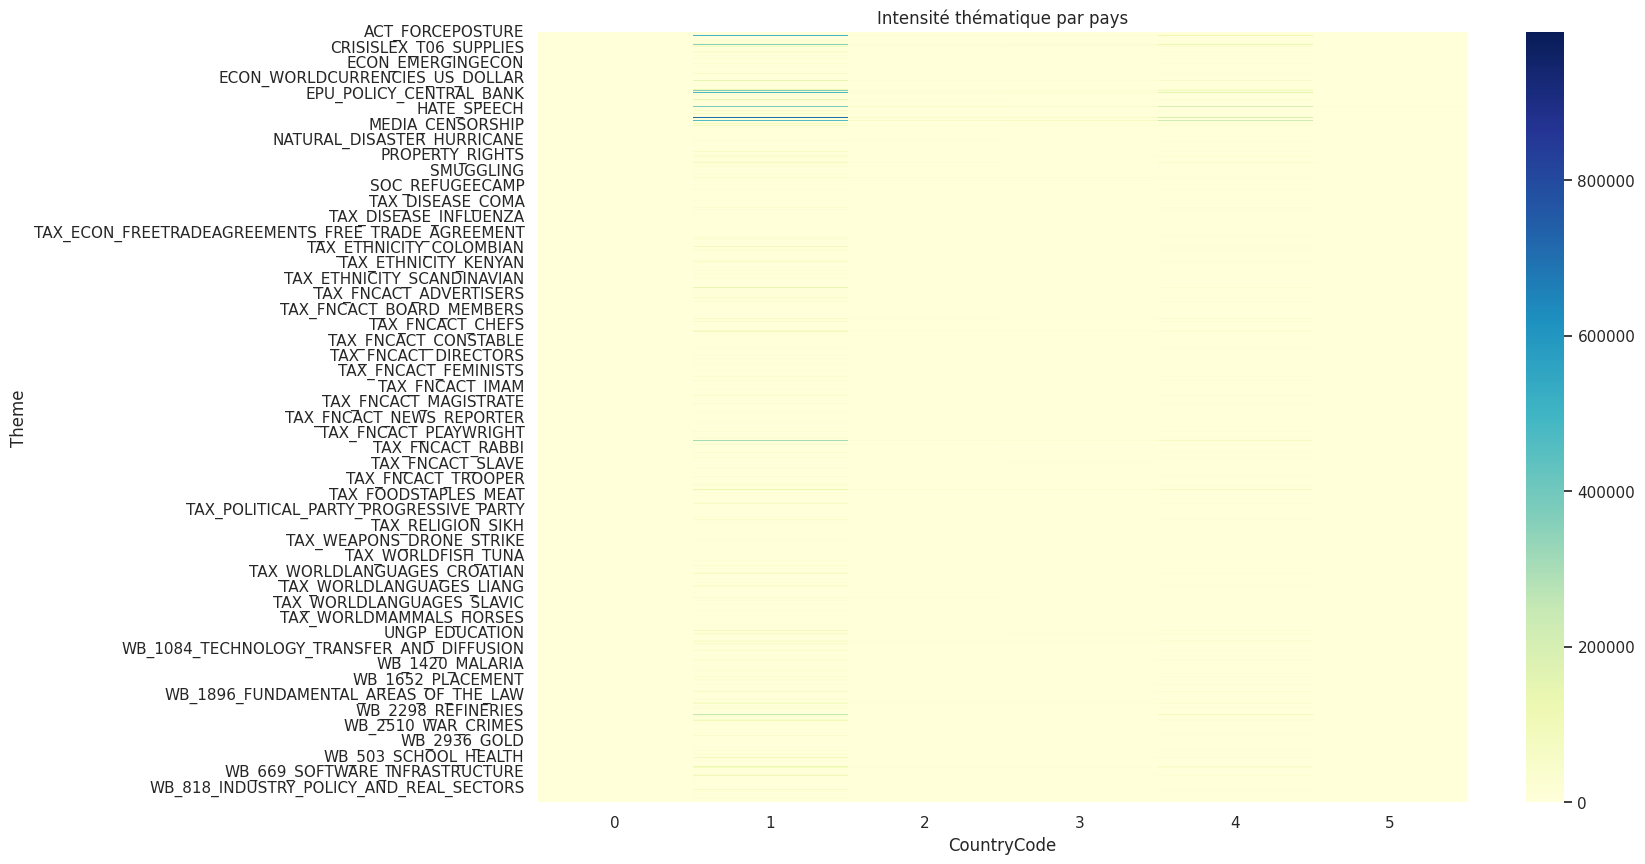

In [27]:
print("⏳ Calcul de la géographie thématique (Méthode CTE)...")

df_geo = con.execute("""
    WITH exploded_data AS (
        SELECT 
            split_part(TRIM(loc), '#', 1) AS CountryCode,
            split_part(TRIM(thm), ',', 1) AS Theme
        FROM (
            SELECT 
                UNNEST(string_split(EnhancedLocations, ';')) AS loc,
                UNNEST(string_split(EnhancedThemes, ';')) AS thm
            FROM gkg_clean
            WHERE hash(GKGRECORDID) % 200 = 0 
              AND EnhancedLocations IS NOT NULL AND EnhancedThemes IS NOT NULL
        )
    )
    SELECT CountryCode, Theme, COUNT(*) AS Count
    FROM exploded_data
    WHERE CountryCode != '' AND Theme != ''
    GROUP BY CountryCode, Theme
    HAVING Count > 500
""").df()

# Heatmap
pivot_df = df_geo.pivot(index="Theme", columns="CountryCode", values="Count").fillna(0)

plt.figure(figsize=(15, 10))
sns.heatmap(pivot_df, cmap="YlGnBu", annot=False)
plt.title("Intensité thématique par pays")
plt.show()